# DataXperience: Ciencia de Datos en Acción

## Análisis del cumplimiento de entregas en una Central de Mezclas Farmacéuticas

**Integrantes:** Laura Catalina Mejía - Juan Pablo Castañeda Neiva  
**Programa:** Ingeniería Industrial - Inngenería En Ciencia De Datos  
**Asignatura:** DataXperience

---

### 📌 Contexto

Las Centrales de Mezclas Farmacéuticas gestionan diferentes procesos relacionados con la preparación y entrega de medicamentos y nutriciones a los servicios asistenciales. Estas actividades generan información que puede ser analizada para identificar el comportamiento del cumplimiento de las entregas y detectar oportunidades de mejora.

Para este proyecto se utilizará un conjunto de datos proveniente del seguimiento de oportunidades de entrega de una Central de Mezclas Farmacéuticas, con información correspondiente a diferentes servicios y períodos de tiempo.

### 🎯 Objetivo

Analizar el comportamiento del cumplimiento de las oportunidades de entrega de una Central de Mezclas Farmacéuticas, utilizando herramientas de Ciencia de Datos para identificar tendencias, diferencias entre servicios y posibles oportunidades de mejora.

### ❓ Pregunta de análisis

¿Qué servicios presentan mayores oportunidades de mejora en el cumplimiento de las entregas y cómo ha evolucionado este indicador durante el período analizado?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib

In [ ]:
# ▶️ EJECUTA ESTA CELDA PRIMERO (haz clic aquí y presiona Shift + Enter)
# Prepara una herramienta que usarás para verificar tus ejercicios.

def revisar(obtenido, esperado, pista=""):
    """Compara tu resultado con el esperado y te dice si acertaste."""
    if obtenido == esperado:
        print("✅ ¡Correcto!")
    else:
        print("❌ Todavía no.")
        print("   Tu resultado:", obtenido)
        print("   Se esperaba :", esperado)
        if pista:
            print("   💡 Pista:", pista)

print("🎉 ¡Listo! Tu cuaderno está activo. Ya puedes seguir bajando.")

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

nombre_archivo = "Oportunidad de entrega (1).xlsx"

rutas = list(
    Path("/content/drive/MyDrive").rglob(nombre_archivo)
)

print("Archivos encontrados:")

for ruta in rutas:
    print(ruta)

Archivos encontrados:
/content/drive/MyDrive/Oportunidad de entrega (1).xlsx


In [ ]:
from pathlib import Path
import pandas as pd

nombre_archivo = "Oportunidad de entrega (1).xlsx"
base_dir = Path("/content/drive/MyDrive")

rutas = list(base_dir.rglob(nombre_archivo))

if not rutas:
    # If rglob fails, try the most common direct path
    direct_path = base_dir / nombre_archivo
    if direct_path.exists():
        ruta = direct_path
        print(f"Advertencia: rglob no encontró el archivo, pero se encontró directamente en: {ruta}")
    else:
        raise FileNotFoundError(f"El archivo '{nombre_archivo}' no se encontró en Google Drive. Asegúrate de que está en '/content/drive/MyDrive' o en alguna subcarpeta.")
else:
    ruta = rutas[0]

df = pd.read_excel(ruta)

print("✅ Archivo cargado correctamente")
print("Filas y columnas:", df.shape)

✅ Archivo cargado correctamente
Filas y columnas: (312, 9)


In [ ]:
df_limpio = df.copy()

print("✅ Copia de trabajo creada")

✅ Copia de trabajo creada


In [ ]:
print("Dimensiones del dataset:")
print(df_limpio.shape)

print("\nColumnas:")
print(df_limpio.columns.tolist())

Dimensiones del dataset:
(312, 9)

Columnas:
['AÑO', 'SERVICIO', 'FECHA', 'MES RESUMEN', 'TOTAL CUMPLE', 'TOTAL NO CUMPLE', 'TOTAL ITEMS', 'PORCENTAJE DE CUMPLIMIENTO', 'ANALISIS INDICADOR']


In [ ]:
df_limpio.head()

,AÑO,SERVICIO,FECHA,MES RESUMEN,TOTAL CUMPLE,TOTAL NO CUMPLE,TOTAL ITEMS,PORCENTAJE DE CUMPLIMIENTO,ANALISIS INDICADOR
0,2023,Ambulatorio Noche,2023-12-01,DICIEMBRE,22.0,0.0,22.0,1,NaN
1,2023,Ambulatorio Noche,2023-11-02,NOVIEMBRE,20.0,0.0,20.0,1,NaN
2,2023,Ambulatorio Noche,2023-10-04,OCTUBRE,22.0,0.0,22.0,1,NaN
3,2023,Ambulatorio Noche,2023-09-05,SEPTIEMBRE,20.0,1.0,21.0,0.952381,NaN
4,2023,Ambulatorio Noche,2023-08-07,AGOSTO,21.0,0.0,21.0,1,NaN


In [ ]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   AÑO                         312 non-null    int64         
 1   SERVICIO                    312 non-null    object        
 2   FECHA                       312 non-null    datetime64[ns]
 3   MES RESUMEN                 312 non-null    object        
 4   TOTAL CUMPLE                309 non-null    float64       
 5   TOTAL NO CUMPLE             309 non-null    float64       
 6   TOTAL ITEMS                 241 non-null    float64       
 7   PORCENTAJE DE CUMPLIMIENTO  204 non-null    object        
 8   ANALISIS INDICADOR          3 non-null      object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 22.1+ KB


In [ ]:
df_limpio.isnull().sum()

,0
AÑO,0
SERVICIO,0
FECHA,0
MES RESUMEN,0
TOTAL CUMPLE,3
TOTAL NO CUMPLE,3
TOTAL ITEMS,71
PORCENTAJE DE CUMPLIMIENTO,108
ANALISIS INDICADOR,309


In [ ]:
print("Número de filas duplicadas:")
print(df_limpio.duplicated().sum())

Número de filas duplicadas:
0


In [ ]:
print("TIPO DE CADA COLUMNA:")
print(df_limpio.dtypes)

print("\n" + "="*60)
print("VALORES NULOS:")
print(df_limpio.isnull().sum())

print("\n" + "="*60)
print("FILAS DUPLICADAS:")
print(df_limpio.duplicated().sum())

TIPO DE CADA COLUMNA:
AÑO                                    int64
SERVICIO                              object
FECHA                         datetime64[ns]
MES RESUMEN                           object
TOTAL CUMPLE                         float64
TOTAL NO CUMPLE                      float64
TOTAL ITEMS                          float64
PORCENTAJE DE CUMPLIMIENTO            object
ANALISIS INDICADOR                    object
dtype: object

VALORES NULOS:
AÑO                             0
SERVICIO                        0
FECHA                           0
MES RESUMEN                     0
TOTAL CUMPLE                    3
TOTAL NO CUMPLE                 3
TOTAL ITEMS                    71
PORCENTAJE DE CUMPLIMIENTO    108
ANALISIS INDICADOR            309
dtype: int64

FILAS DUPLICADAS:
0


In [ ]:
print(df_limpio["PORCENTAJE DE CUMPLIMIENTO"].value_counts(dropna=False).head(30))

PORCENTAJE DE CUMPLIMIENTO
NaN         108
1            57
0.962963      6
0.958333      4
0.961538      4
0.9375        3
0.955556      3
0.967742      3
0.970588      2
0.916667      2
0.972222      2
0.965217      2
0.976744      2
0.923077      2
0.945946      2
0.95          2
0.923469      1
0.971264      1
0.913295      1
0.915254      1
0.944444      1
0.904762      1
0.765152      1
0.906977      1
0.946429      1
0.857923      1
0.966102      1
0.968992      1
0.970874      1
0.913793      1
Name: count, dtype: int64


🔎 Interpretación de valores faltantes

Se identificaron 108 registros sin información en la variable PORCENTAJE DE CUMPLIMIENTO. Estos valores no se consideran errores de calidad de datos, debido a que corresponden principalmente a periodos iniciales de operación de la Central de Mezclas Farmacéuticas, especialmente durante el año 2023, cuando algunos servicios aún no contaban con cobertura o presentaban bajos niveles de producción. Por esta razón, no se reemplazan automáticamente por cero ni se eliminan, ya que representan situaciones en las que el indicador no era aplicable.

In [ ]:
# 🔎 Revisar los registros sin porcentaje de cumplimiento por año

sin_porcentaje = df_limpio[
    df_limpio["PORCENTAJE DE CUMPLIMIENTO"].isna()
]

print("Registros sin porcentaje de cumplimiento por año:")
print(sin_porcentaje["AÑO"].value_counts().sort_index())

Registros sin porcentaje de cumplimiento por año:
AÑO
2023    16
2024    17
2025    10
2026    65
Name: count, dtype: int64


✅ Los 108 valores faltantes de PORCENTAJE DE CUMPLIMIENTO se distribuyen así:

In [ ]:
# 🔎 Revisar los servicios que presentan valores faltantes

print("Servicios con porcentaje de cumplimiento faltante:")
print(sin_porcentaje["SERVICIO"].value_counts())

Servicios con porcentaje de cumplimiento faltante:
SERVICIO
Nutrición Parenteral    18
Ambulatorio Noche       13
Ambulatorio Dia         13
SAMI                    13
Hospitalización         12
TPH                     11
Centros Medicos         11
Unidosis                 9
Plasmaferesis            8
Name: count, dtype: int64


⭐Sabemos que especialmente en los primeros periodos hubo servicios que todavía no tenían la misma actividad.
 Pero muchos pueden corresponden a 2026
🟣 2026 → 65 de los 108 faltantes

Eso representa aproximadamente el 60,2 % de todos los valores faltantes.

Y se debe tener en cuenta que el archivo está actualizado solamente hasta 📅 abril de 2026 pero esta para diligenciar hasta diciembre 2026 y este dato es muy importante.

Pero ahora tenemos que demostrarlo con los datos, no asumirlo.

In [ ]:
# 📅 Revisar el periodo cubierto por el dataset

print("Fecha inicial:", df_limpio["FECHA"].min())
print("Fecha final:", df_limpio["FECHA"].max())

Fecha inicial: 2023-01-16 00:00:00
Fecha final: 2026-12-01 00:00:00


In [ ]:
df_2026 = df_limpio[df_limpio["AÑO"] == 2026].copy()

print("Cantidad de registros de 2026 por mes:")
print(df_2026["FECHA"].dt.month.value_counts().sort_index())

Cantidad de registros de 2026 por mes:
FECHA
1     9
2     9
3     9
4     9
5     9
6     9
7     9
8     9
9     9
10    9
11    9
12    9
Name: count, dtype: int64


In [ ]:
# 📊 Valores faltantes de cumplimiento por mes en 2026

df_2026["MES"] = df_2026["FECHA"].dt.month

resumen_2026 = df_2026.groupby("MES").agg(
    registros=("PORCENTAJE DE CUMPLIMIENTO", "size"),
    faltantes=("PORCENTAJE DE CUMPLIMIENTO", lambda x: x.isna().sum())
)

resumen_2026["con_dato"] = (
    resumen_2026["registros"] - resumen_2026["faltantes"]
)

print(resumen_2026)

     registros  faltantes  con_dato
MES                                
1            9          0         9
2            9          0         9
3            9          0         9
4            9          0         9
5            9          2         7
6            9          9         0
7            9          9         0
8            9          9         0
9            9          9         0
10           9          9         0
11           9          9         0
12           9          9         0


"A partir de mayo de 2026 se identifican registros en la estructura del archivo, pero no presentan valores en el indicador de porcentaje de cumplimiento, por lo que estos meses no cuentan con información válida para el análisis del desempeño."

In [ ]:
# Revisar hasta qué fecha existen datos válidos del indicador

df_con_indicador = df_limpio[
    df_limpio["PORCENTAJE DE CUMPLIMIENTO"].notna()
].copy()

print("Última fecha con porcentaje de cumplimiento:")
print(df_con_indicador["FECHA"].max())

Última fecha con porcentaje de cumplimiento:
2026-05-01 00:00:00


In [ ]:
print("Cantidad de registros con indicador por mes en 2026:")

df_2026_validos = df_limpio[
    (df_limpio["AÑO"] == 2026) &
    (df_limpio["PORCENTAJE DE CUMPLIMIENTO"].notna())
].copy()

print(
    df_2026_validos["FECHA"]
    .dt.month
    .value_counts()
    .sort_index()
)

Cantidad de registros con indicador por mes en 2026:
FECHA
1    9
2    9
3    9
4    9
5    7
Name: count, dtype: int64


💡 Hallazgo de calidad de datos: El dataset contiene registros correspondientes a meses posteriores a abril de 2026; sin embargo, estos registros presentan valores faltantes en la variable PORCENTAJE DE CUMPLIMIENTO. Debido a que el archivo se encuentra actualizado hasta abril de 2026, estos registros no serán considerados para el análisis del indicador, evitando interpretar valores faltantes como incumplimientos.

Durante la exploración del dataset se identificaron registros correspondientes a meses posteriores a abril de 2026 que no contienen información en la variable PORCENTAJE DE CUMPLIMIENTO. Estos registros se conservarán en el dataset original, pero no serán utilizados para calcular el indicador, debido a que un valor faltante no representa necesariamente un incumplimiento.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

nombre_archivo = "Oportunidad de entrega (1).xlsx"

rutas = list(
    Path("/content/drive/MyDrive").rglob(nombre_archivo)
)

print("Archivos encontrados:")

for ruta in rutas:
    print(ruta)

Archivos encontrados:
/content/drive/MyDrive/Oportunidad de entrega (1).xlsx


In [ ]:
ruta = rutas[0]

df = pd.read_excel(ruta)

print("✅ Archivo cargado correctamente")
print("Filas y columnas:", df.shape)

✅ Archivo cargado correctamente
Filas y columnas: (312, 9)


In [ ]:
df_limpio = df.copy()

print("✅ Copia de trabajo creada")

✅ Copia de trabajo creada


In [ ]:
# Resumen de registros 2026 y disponibilidad del indicador

df_2026 = df_limpio[df_limpio["AÑO"] == 2026].copy()

df_2026["MES"] = df_2026["FECHA"].dt.month

resumen_2026 = df_2026.groupby("MES").agg(
    registros=("PORCENTAJE DE CUMPLIMIENTO", "size"),
    faltantes=("PORCENTAJE DE CUMPLIMIENTO", lambda x: x.isna().sum())
)

resumen_2026["con_dato"] = (
    resumen_2026["registros"] - resumen_2026["faltantes"]
)

resumen_2026

,registros,faltantes,con_dato
MES,,,
1,9,0,9
2,9,0,9
3,9,0,9
4,9,0,9
5,9,2,7
6,9,9,0
7,9,9,0
8,9,9,0
9,9,9,0


Aquí es donde hacemos una decisión metodológica importante.

Como el indicador solamente tiene información válida hasta abril de 2026, creamos una copia para el análisis:

In [ ]:
# Dataset para el análisis del cumplimiento
# Se conservan únicamente registros que tienen información válida
# en el indicador de porcentaje de cumplimiento.

df_analisis = df_limpio[
    df_limpio["PORCENTAJE DE CUMPLIMIENTO"].notna()
].copy()

print("Registros originales:", len(df_limpio))
print("Registros utilizados para el análisis:", len(df_analisis))
print("Última fecha con indicador válido:", df_analisis["FECHA"].max())

Registros originales: 312
Registros utilizados para el análisis: 204
Última fecha con indicador válido: 2026-05-01 00:00:00


In [ ]:
# 1. Importar las librerías para visualización
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo visual general
sns.set_theme(style="whitegrid")

# 2. Preparar el dataset (usando el df_limpio que ya tienes en memoria)
# Filtramos hasta abril de 2026 y quitamos registros sin datos numéricos
df_analisis = df_limpio[df_limpio["FECHA"] <= "2026-04-30"].copy()
df_analisis = df_analisis.dropna(subset=['TOTAL CUMPLE', 'TOTAL NO CUMPLE', 'TOTAL ITEMS'])

print("Generando visualizaciones exploratorias...\n")

Generando visualizaciones exploratorias...



/tmp/ipykernel_643/2525538901.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


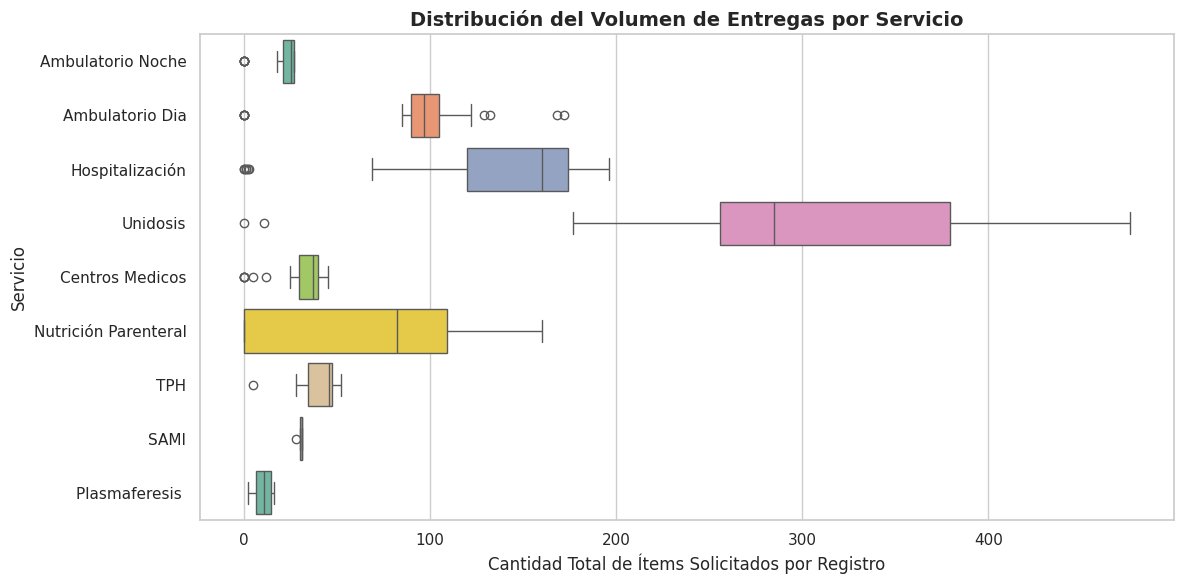

In [ ]:
# ==========================================
# GRÁFICO 1: Distribución del Volumen (Boxplot)
# ==========================================
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_analisis,
    x='TOTAL ITEMS',
    y='SERVICIO',
    palette='Set2'
)
plt.title('Distribución del Volumen de Entregas por Servicio', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad Total de Ítems Solicitados por Registro', fontsize=12)
plt.ylabel('Servicio', fontsize=12)
plt.tight_layout()
plt.show()

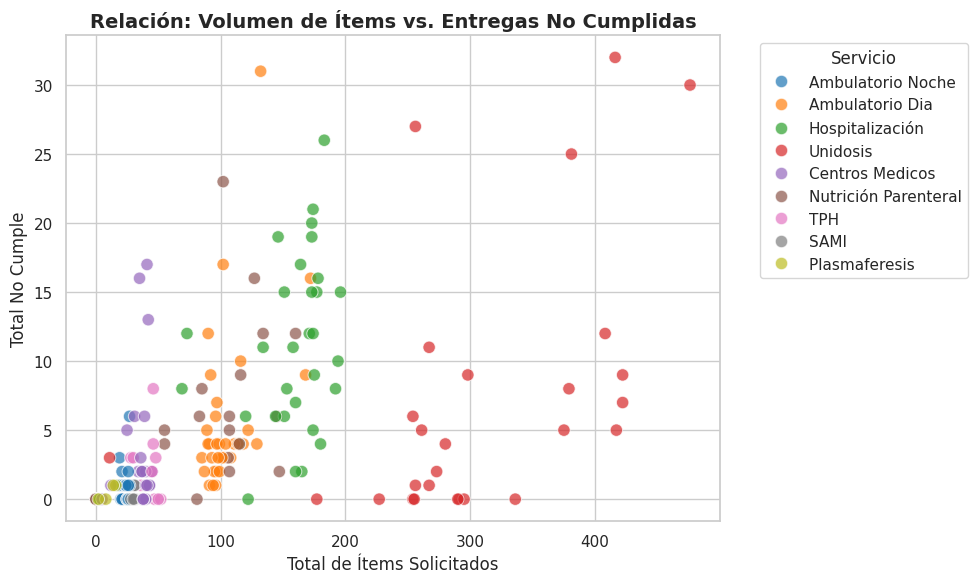

In [ ]:
# ==========================================
# GRÁFICO 2: Relación Volumen vs Fallas (Scatter Plot)
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_analisis,
    x='TOTAL ITEMS',
    y='TOTAL NO CUMPLE',
    hue='SERVICIO',
    palette='tab10',
    alpha=0.7,
    s=80
)
plt.title('Relación: Volumen de Ítems vs. Entregas No Cumplidas', fontsize=14, fontweight='bold')
plt.xlabel('Total de Ítems Solicitados', fontsize=12)
plt.ylabel('Total No Cumple', fontsize=12)
# Mover leyenda afuera
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Servicio')
plt.tight_layout()
plt.show()

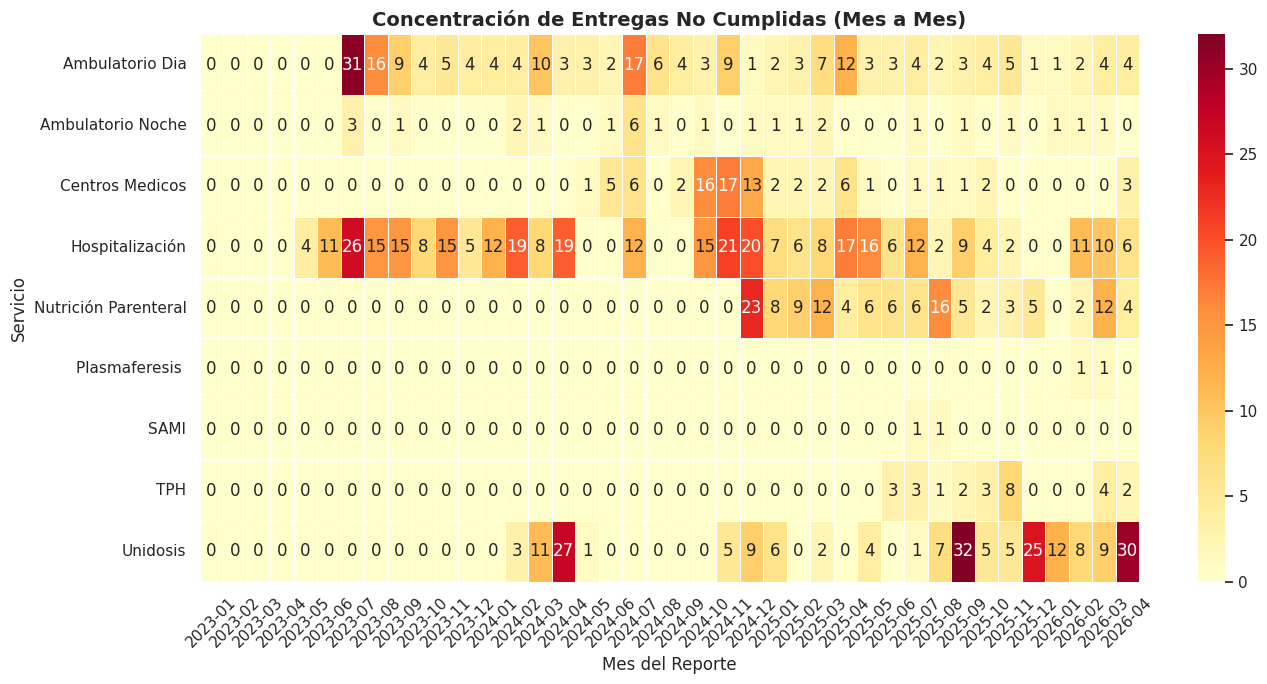

In [ ]:
# ==========================================
# GRÁFICO 3: Mapa de Calor Temporal (Heatmap)
# ==========================================
# Preparar datos: crear formato Año-Mes
df_calor = df_analisis.copy()
df_calor['AÑO_MES'] = df_calor['FECHA'].dt.strftime('%Y-%m')

# Crear tabla dinámica para el mapa de calor
matriz_fallas = df_calor.pivot_table(
    index='SERVICIO',
    columns='AÑO_MES',
    values='TOTAL NO CUMPLE',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(14, 7))
sns.heatmap(
    matriz_fallas,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=.5
)
plt.title('Concentración de Entregas No Cumplidas (Mes a Mes)', fontsize=14, fontweight='bold')
plt.xlabel('Mes del Reporte', fontsize=12)
plt.ylabel('Servicio', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Preparación rápida: Asegurarnos de que el porcentaje esté en escala de 0 a 100
df_analisis['PORCENTAJE_NUM'] = pd.to_numeric(df_analisis['PORCENTAJE DE CUMPLIMIENTO'], errors='coerce') * 100

print("Generando gráficos exploratorios complementarios...\n")

Generando gráficos exploratorios complementarios...



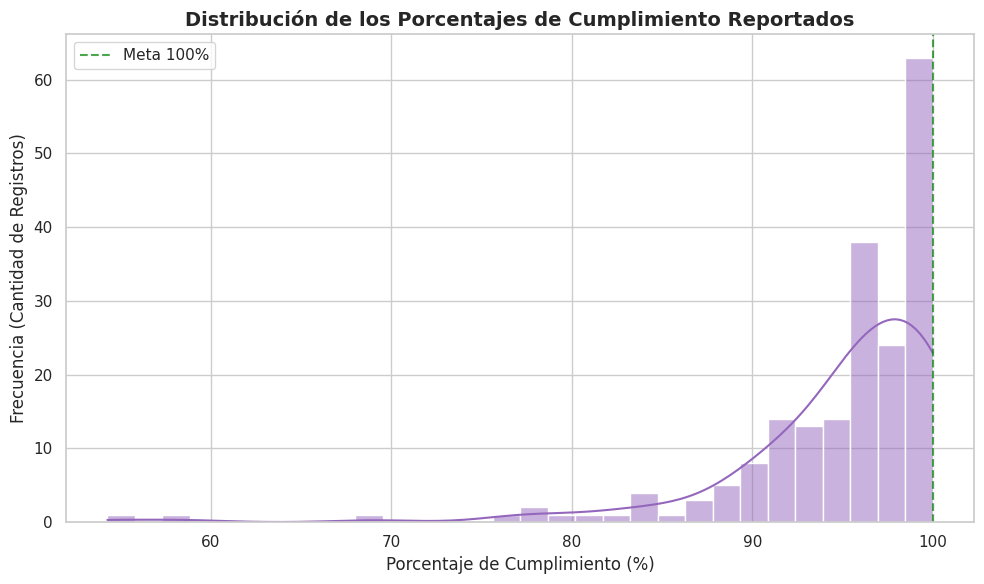

In [ ]:
# ==========================================
# GRÁFICO 4: Distribución del Porcentaje de Cumplimiento (Histograma)
# ==========================================
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_analisis,
    x='PORCENTAJE_NUM',
    bins=30,
    kde=True, # Añade la curva de densidad
    color='#9467bd'
)
plt.title('Distribución de los Porcentajes de Cumplimiento Reportados', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de Cumplimiento (%)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Registros)', fontsize=12)
plt.axvline(x=100, color='green', linestyle='--', alpha=0.7, label='Meta 100%')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_643/640713892.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


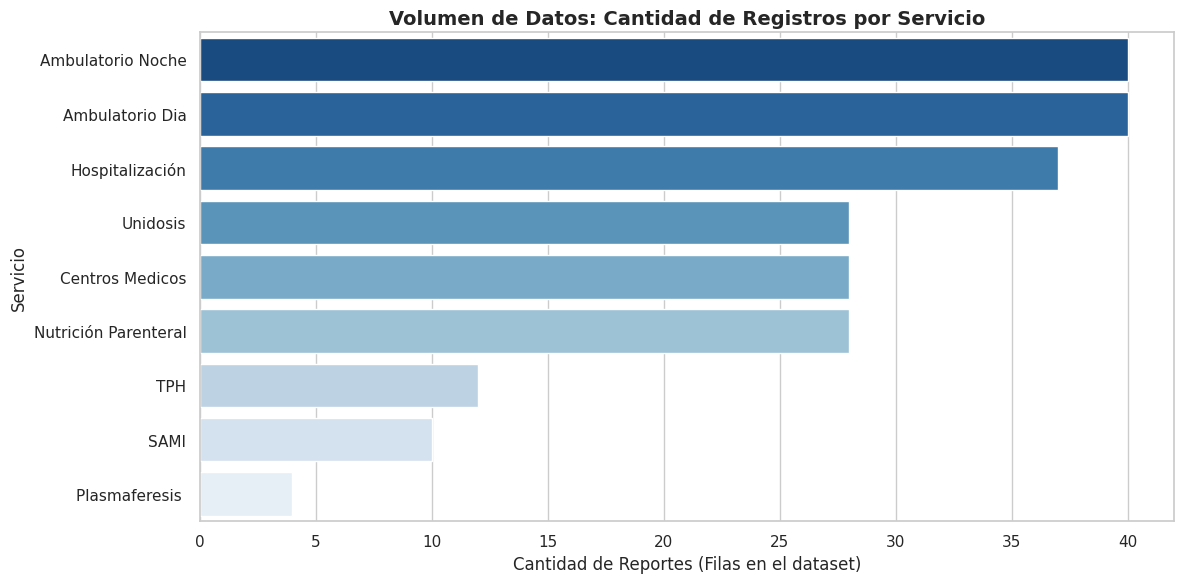

In [ ]:
# ==========================================
# GRÁFICO 5: Cantidad de Reportes por Servicio (Count Plot)
# ==========================================
plt.figure(figsize=(12, 6))
# Contamos cuántos registros (filas) tiene cada servicio y ordenamos
orden_servicios = df_analisis['SERVICIO'].value_counts().index

sns.countplot(
    data=df_analisis,
    y='SERVICIO',
    order=orden_servicios,
    palette='Blues_r'
)
plt.title('Volumen de Datos: Cantidad de Registros por Servicio', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Reportes (Filas en el dataset)', fontsize=12)
plt.ylabel('Servicio', fontsize=12)
plt.tight_layout()
plt.show()

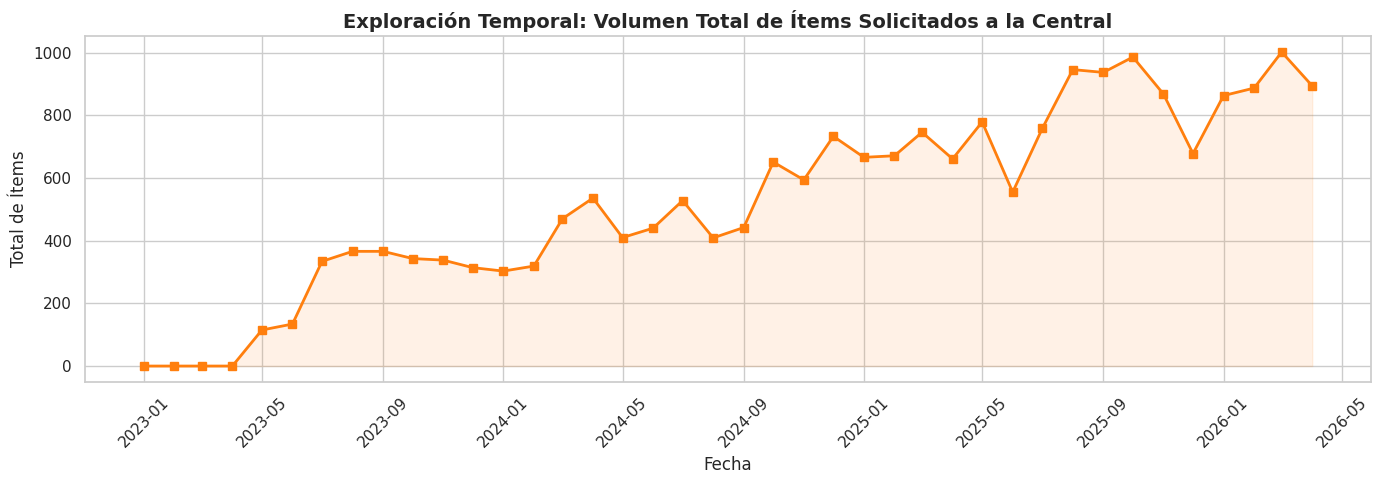

In [ ]:
# ==========================================
# GRÁFICO 6: Tendencia de la Carga de Trabajo Total (Líneas)
# ==========================================
# Agrupamos el volumen total de ítems por mes
volumen_mensual = df_analisis.groupby(df_analisis['FECHA'].dt.to_period('M'))['TOTAL ITEMS'].sum()
volumen_mensual.index = volumen_mensual.index.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(volumen_mensual.index, volumen_mensual.values, marker='s', color='#ff7f0e', linewidth=2)
plt.title('Exploración Temporal: Volumen Total de Ítems Solicitados a la Central', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Total de Ítems', fontsize=12)
plt.fill_between(volumen_mensual.index, volumen_mensual.values, color='#ff7f0e', alpha=0.1) # Sombra bajo la línea
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Preparación previa: Extraer el día de la semana para el análisis temporal
# Mapeamos los días al español para mayor claridad
mapa_dias = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df_analisis['DIA_SEMANA'] = df_analisis['FECHA'].dt.day_name().map(mapa_dias)
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

print("Generando gráficos exploratorios avanzados...\n")

Generando gráficos exploratorios avanzados...



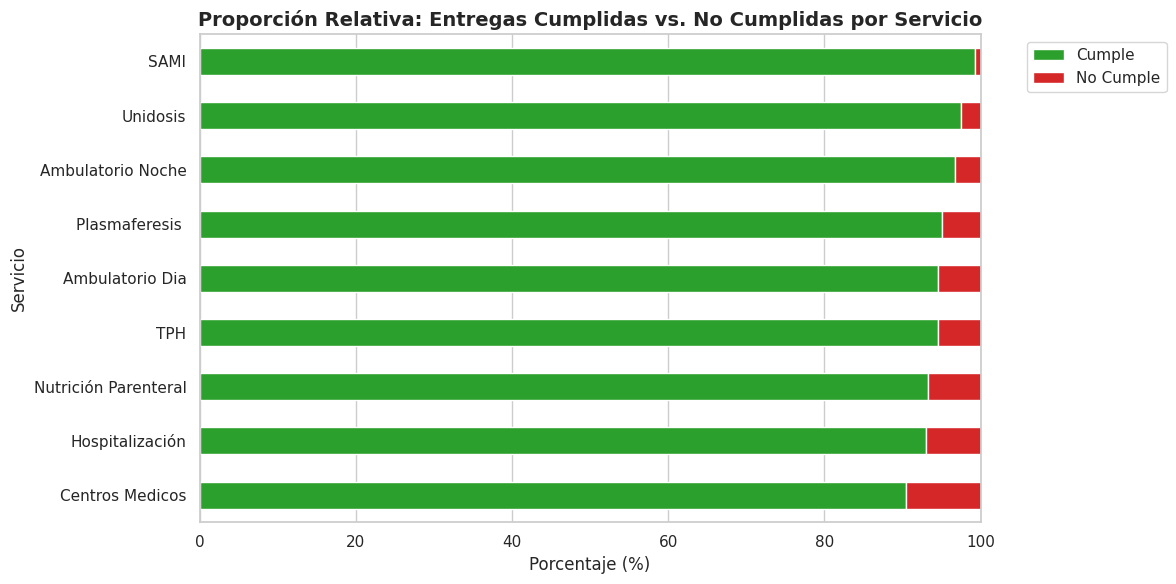

In [ ]:
# ==========================================
# GRÁFICO 7: Proporción 100% Apilada (Cumple vs No Cumple)
# ==========================================
# Este gráfico neutraliza el volumen. Muestra qué porcentaje de las entregas de CADA servicio fueron exitosas vs fallidas.
prop_servicio = df_analisis.groupby('SERVICIO')[['TOTAL CUMPLE', 'TOTAL NO CUMPLE']].sum()
prop_servicio_pct = prop_servicio.div(prop_servicio.sum(axis=1), axis=0) * 100
prop_servicio_pct = prop_servicio_pct.sort_values('TOTAL CUMPLE')

prop_servicio_pct.plot(
    kind='barh',
    stacked=True,
    color=['#2ca02c', '#d62728'], # Verde (Cumple) y Rojo (No Cumple)
    figsize=(12, 6)
)
plt.title('Proporción Relativa: Entregas Cumplidas vs. No Cumplidas por Servicio', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje (%)', fontsize=12)
plt.ylabel('Servicio', fontsize=12)
plt.legend(['Cumple', 'No Cumple'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

/tmp/ipykernel_643/365296853.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


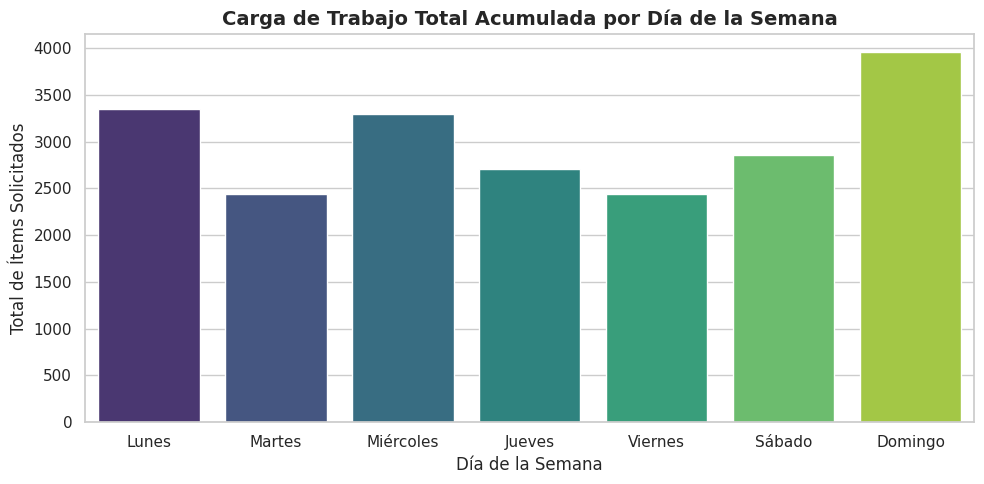

In [ ]:
# ==========================================
# GRÁFICO 8: Análisis por Día de la Semana
# ==========================================
# Exploramos si hay días específicos de la semana con mayor carga de trabajo
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_analisis,
    x='DIA_SEMANA',
    y='TOTAL ITEMS',
    order=orden_dias,
    estimator=sum, # Sumamos todos los items por día
    errorbar=None,
    palette='viridis'
)
plt.title('Carga de Trabajo Total Acumulada por Día de la Semana', fontsize=14, fontweight='bold')
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Total de Ítems Solicitados', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_643/1748192436.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


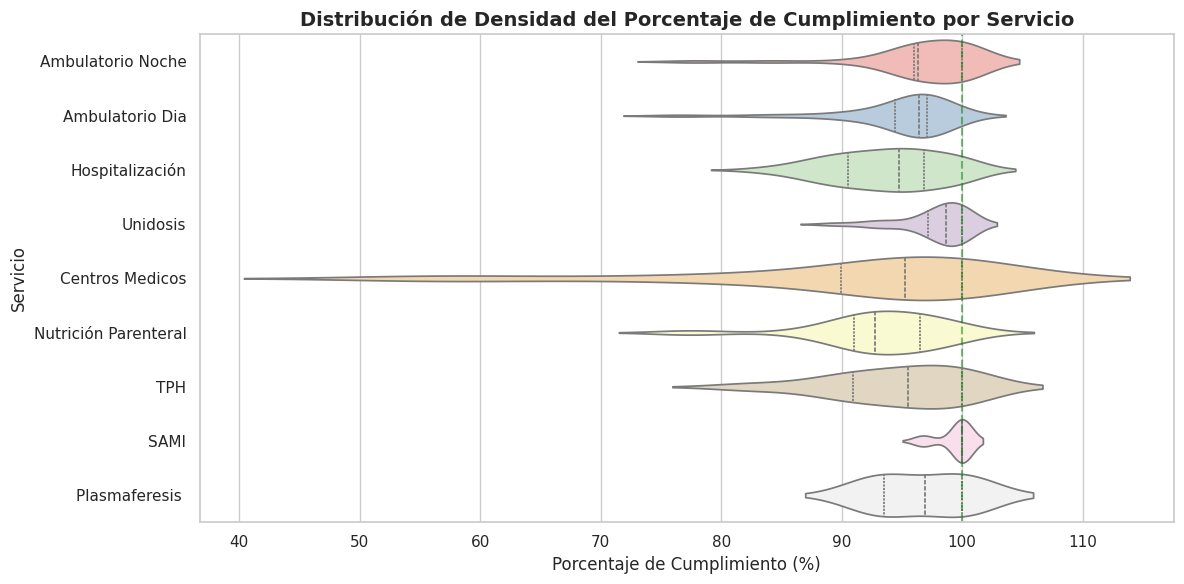

In [ ]:
# ==========================================
# GRÁFICO 9: Gráfico de Violín (Distribución de Cumplimiento)
# ==========================================
# Similar al boxplot, pero muestra la "forma" de los datos (la densidad).
# Las zonas más gruesas indican donde se concentran más los porcentajes.
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_analisis,
    x='PORCENTAJE_NUM',
    y='SERVICIO',
    palette='Pastel1',
    inner='quartile' # Muestra las líneas de los cuartiles por dentro
)
plt.title('Distribución de Densidad del Porcentaje de Cumplimiento por Servicio', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de Cumplimiento (%)', fontsize=12)
plt.ylabel('Servicio', fontsize=12)
plt.axvline(x=100, color='green', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

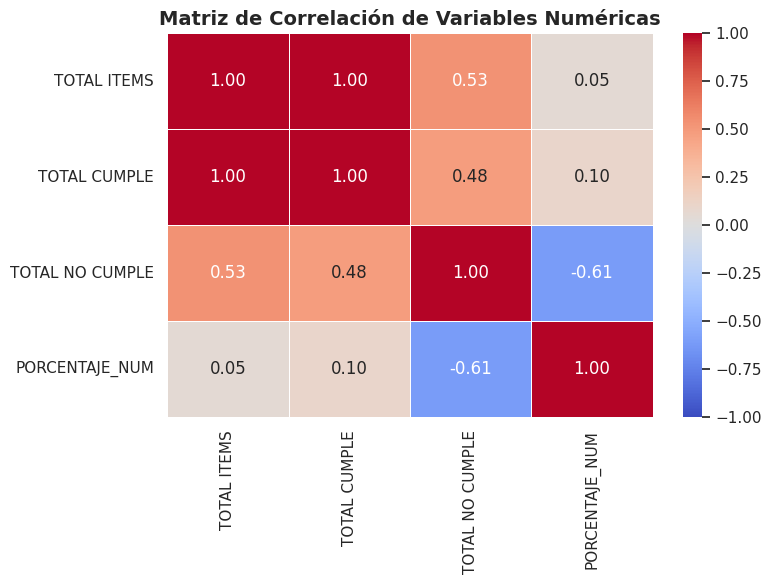

In [ ]:
# ==========================================
# GRÁFICO 10: Matriz de Correlación Numérica
# ==========================================
# Muestra matemáticamente qué tan relacionadas están las variables numéricas entre sí (-1 a 1)
plt.figure(figsize=(8, 6))
columnas_num = ['TOTAL ITEMS', 'TOTAL CUMPLE', 'TOTAL NO CUMPLE', 'PORCENTAJE_NUM']
correlacion = df_analisis[columnas_num].corr()

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt=".2f",
    linewidths=.5
)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from matplotlib.ticker import PercentFormatter

print("Generando los últimos gráficos exploratorios...\n")

Generando los últimos gráficos exploratorios...



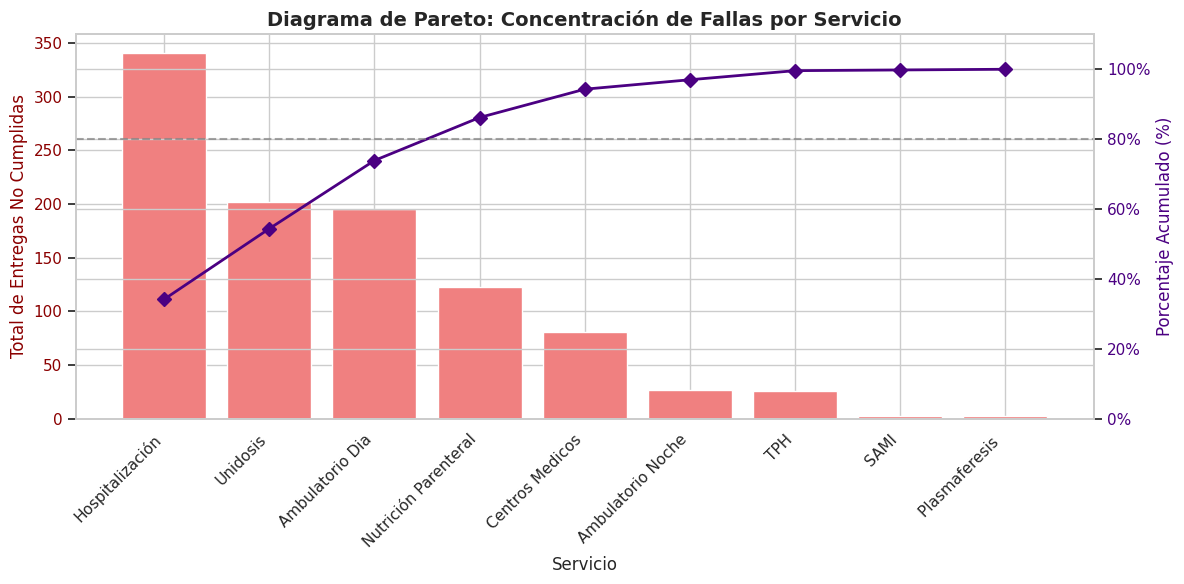

In [ ]:
# ==========================================
# GRÁFICO 11: Diagrama de Pareto de Incumplimientos
# ==========================================
# El principio de Pareto (regla del 80/20) ayuda a identificar si unos pocos
# servicios son responsables de la mayoría de las fallas.

# Preparar datos: Ordenar servicios por fallas y calcular el acumulado
pareto_df = df_analisis.groupby('SERVICIO')['TOTAL NO CUMPLE'].sum().sort_values(ascending=False).reset_index()
pareto_df['PORCENTAJE_ACUMULADO'] = pareto_df['TOTAL NO CUMPLE'].cumsum() / pareto_df['TOTAL NO CUMPLE'].sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barra principal (Volumen de fallas)
ax1.bar(pareto_df['SERVICIO'], pareto_df['TOTAL NO CUMPLE'], color='lightcoral')
ax1.set_xlabel('Servicio', fontsize=12)
ax1.set_ylabel('Total de Entregas No Cumplidas', color='darkred', fontsize=12)
ax1.tick_params(axis='y', labelcolor='darkred')
ax1.set_xticks(range(len(pareto_df['SERVICIO'])))
ax1.set_xticklabels(pareto_df['SERVICIO'], rotation=45, ha='right')

# Línea secundaria (Porcentaje acumulado)
ax2 = ax1.twinx()
ax2.plot(pareto_df['SERVICIO'], pareto_df['PORCENTAJE_ACUMULADO'], color='indigo', marker='D', ms=7, linewidth=2)
ax2.set_ylabel('Porcentaje Acumulado (%)', color='indigo', fontsize=12)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.tick_params(axis='y', labelcolor='indigo')
ax2.set_ylim(0, 110)

# Línea del 80% (Para identificar el 80/20)
ax2.axhline(80, color='gray', linestyle='dashed', alpha=0.7)

plt.title('Diagrama de Pareto: Concentración de Fallas por Servicio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

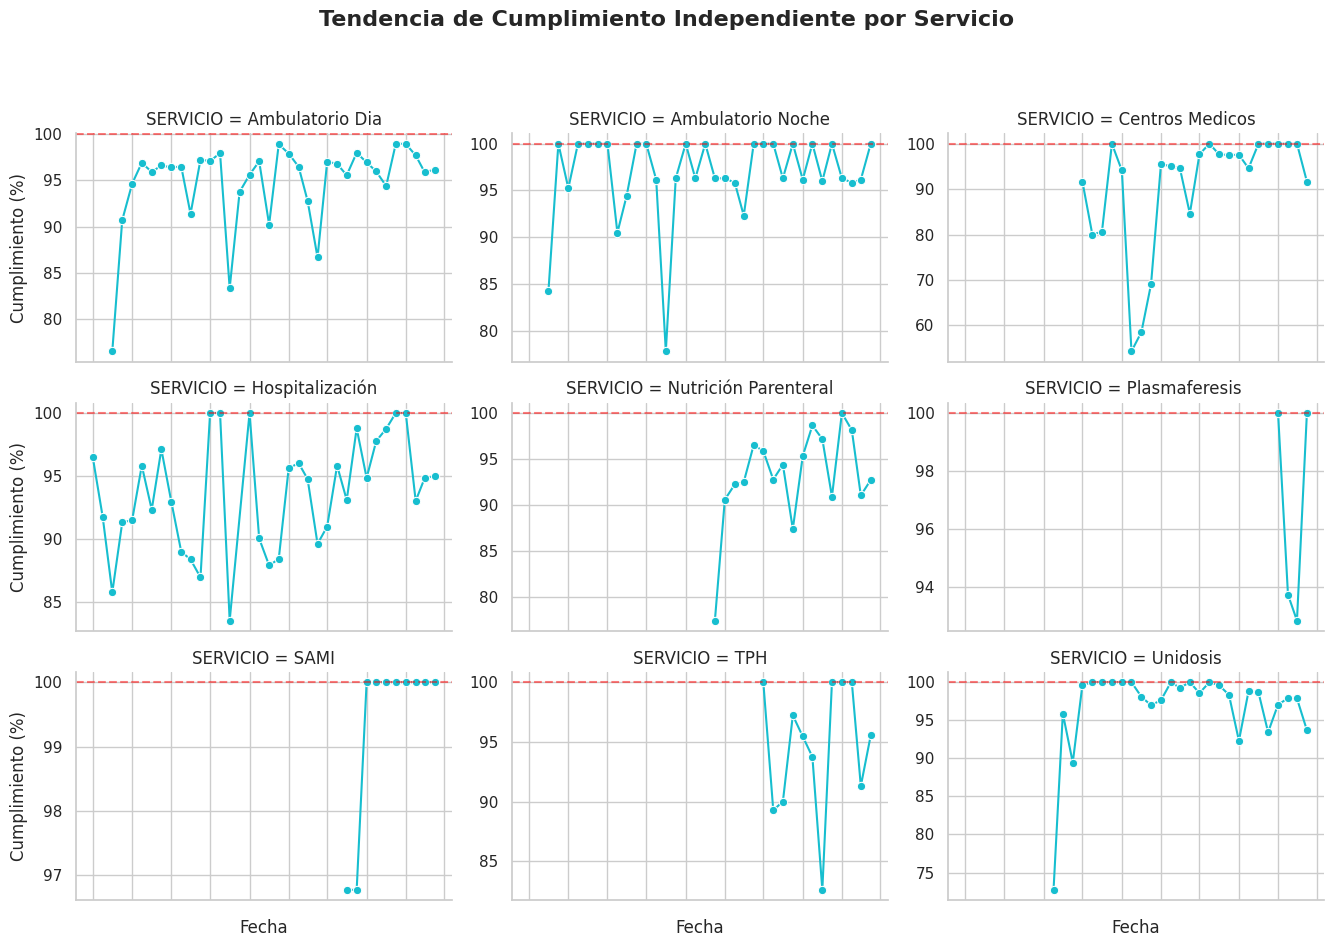

In [ ]:
# ==========================================
# GRÁFICO 12: Tendencias Aisladas por Servicio (Facet Grid / Small Multiples)
# ==========================================
# En lugar de tener una sola gráfica con muchas líneas cruzadas (difícil de leer),
# creamos una mini-gráfica para cada servicio en una cuadrícula.

# Agrupar por servicio y mes
df_mensual_servicio = df_analisis.groupby(['SERVICIO', df_analisis['FECHA'].dt.to_period('M')]).agg(
    CUMPLE=('TOTAL CUMPLE', 'sum'),
    ITEMS=('TOTAL ITEMS', 'sum')
).reset_index()
df_mensual_servicio['PORCENTAJE_MENSUAL'] = (df_mensual_servicio['CUMPLE'] / df_mensual_servicio['ITEMS']) * 100
df_mensual_servicio['FECHA'] = df_mensual_servicio['FECHA'].dt.to_timestamp()

g = sns.FacetGrid(df_mensual_servicio, col="SERVICIO", col_wrap=3, height=3, aspect=1.5, sharey=False)
g.map(sns.lineplot, "FECHA", "PORCENTAJE_MENSUAL", marker="o", color="#17becf")

g.fig.suptitle('Tendencia de Cumplimiento Independiente por Servicio', fontsize=16, fontweight='bold', y=1.05)
g.set_axis_labels("Fecha", "Cumplimiento (%)")
g.set_xticklabels(rotation=45)

for ax in g.axes.flatten():
    ax.axhline(100, color='red', linestyle='--', alpha=0.5) # Línea ideal en cada mini-gráfico

plt.tight_layout()
plt.show()

/tmp/ipykernel_643/516655139.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


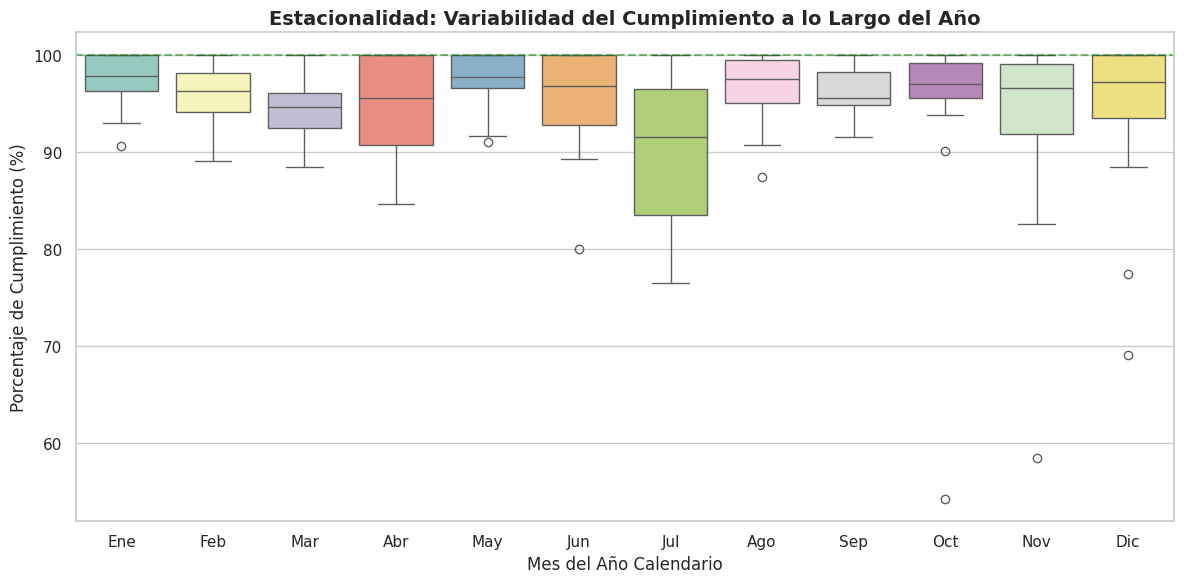

In [ ]:
# ==========================================
# GRÁFICO 13: Estacionalidad Anual (Boxplot por Mes del Año)
# ==========================================
# Extraemos solo el número del mes (1 a 12) sin importar el año,
# para ver si hay meses específicos en el año calendario que siempre sean problemáticos.

df_analisis['MES_DEL_AÑO'] = df_analisis['FECHA'].dt.month
mapa_meses = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
df_analisis['NOMBRE_MES'] = df_analisis['MES_DEL_AÑO'].map(mapa_meses)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_analisis,
    x='MES_DEL_AÑO',
    y='PORCENTAJE_NUM',
    palette='Set3'
)

# Cambiar los números (1,2,3...) por los nombres (Ene, Feb, Mar...) en el eje X
plt.xticks(ticks=range(0, 12), labels=[mapa_meses[i] for i in range(1, 13)])

plt.title('Estacionalidad: Variabilidad del Cumplimiento a lo Largo del Año', fontsize=14, fontweight='bold')
plt.xlabel('Mes del Año Calendario', fontsize=12)
plt.ylabel('Porcentaje de Cumplimiento (%)', fontsize=12)
plt.axhline(100, color='green', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
plt.rcParams.update({'font.size': 11})

print("Generando Gráficos de Conclusión para el Proyecto...\n")

Generando Gráficos de Conclusión para el Proyecto...



/tmp/ipykernel_643/862259238.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(pareto_df['SERVICIO'], rotation=30, ha='right')


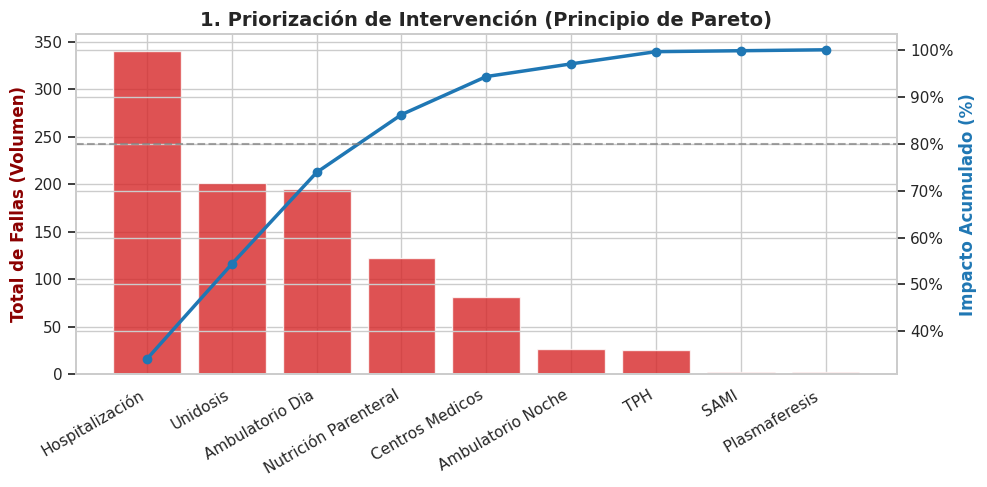

In [ ]:
# ==========================================
# CONCLUSIÓN 1: Priorización (Pareto)
# ==========================================
pareto_df = df_analisis.groupby('SERVICIO')['TOTAL NO CUMPLE'].sum().sort_values(ascending=False).reset_index()
pareto_df['PORCENTAJE_ACUMULADO'] = pareto_df['TOTAL NO CUMPLE'].cumsum() / pareto_df['TOTAL NO CUMPLE'].sum() * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(pareto_df['SERVICIO'], pareto_df['TOTAL NO CUMPLE'], color='#d62728', alpha=0.8)
ax1.set_ylabel('Total de Fallas (Volumen)', color='darkred', fontweight='bold')
ax1.set_xticklabels(pareto_df['SERVICIO'], rotation=30, ha='right')

ax2 = ax1.twinx()
ax2.plot(pareto_df['SERVICIO'], pareto_df['PORCENTAJE_ACUMULADO'], color='#1f77b4', marker='o', linewidth=2.5)
ax2.set_ylabel('Impacto Acumulado (%)', color='#1f77b4', fontweight='bold')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.axhline(80, color='gray', linestyle='dashed', alpha=0.7) # Regla 80/20

plt.title('1. Priorización de Intervención (Principio de Pareto)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

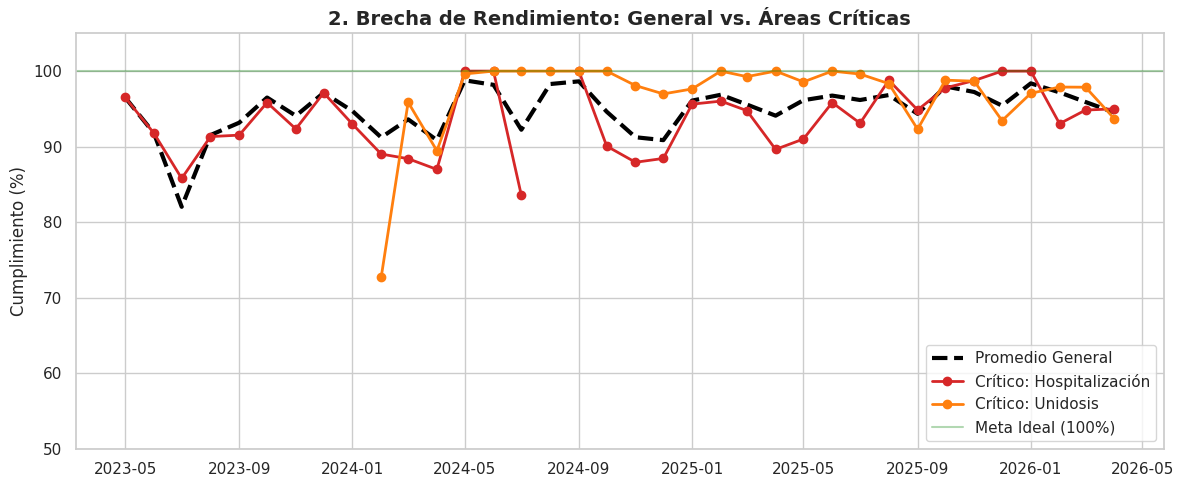

In [ ]:
# ==========================================
# CONCLUSIÓN 2: Evolución General vs Servicios Críticos
# ==========================================
# Extraemos los dos servicios con más fallas según el Pareto
top_2_criticos = pareto_df['SERVICIO'].head(2).tolist()

# Agrupación mensual
df_mensual = df_analisis.groupby(['SERVICIO', df_analisis['FECHA'].dt.to_period('M')]).agg(
    CUMPLE=('TOTAL CUMPLE', 'sum'), ITEMS=('TOTAL ITEMS', 'sum')).reset_index()
df_mensual['CUMPLIMIENTO'] = (df_mensual['CUMPLE'] / df_mensual['ITEMS']) * 100
df_mensual['FECHA'] = df_mensual['FECHA'].dt.to_timestamp()

# Calcular el promedio general
promedio_general = df_analisis.groupby(df_analisis['FECHA'].dt.to_period('M')).agg(
    CUMPLE=('TOTAL CUMPLE', 'sum'), ITEMS=('TOTAL ITEMS', 'sum')).reset_index()
promedio_general['CUMPLIMIENTO_GRAL'] = (promedio_general['CUMPLE'] / promedio_general['ITEMS']) * 100
promedio_general['FECHA'] = promedio_general['FECHA'].dt.to_timestamp()

plt.figure(figsize=(12, 5))
# Graficar el general
plt.plot(promedio_general['FECHA'], promedio_general['CUMPLIMIENTO_GRAL'],
         label='Promedio General', color='black', linewidth=3, linestyle='--')

# Graficar los dos peores
colores_criticos = ['#d62728', '#ff7f0e']
for i, servicio in enumerate(top_2_criticos):
    data_serv = df_mensual[df_mensual['SERVICIO'] == servicio]
    plt.plot(data_serv['FECHA'], data_serv['CUMPLIMIENTO'], label=f'Crítico: {servicio}',
             color=colores_criticos[i], linewidth=2, marker='o')

plt.title('2. Brecha de Rendimiento: General vs. Áreas Críticas', fontsize=14, fontweight='bold')
plt.ylabel('Cumplimiento (%)')
plt.axhline(100, color='green', alpha=0.3, label='Meta Ideal (100%)')
plt.ylim(50, 105)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

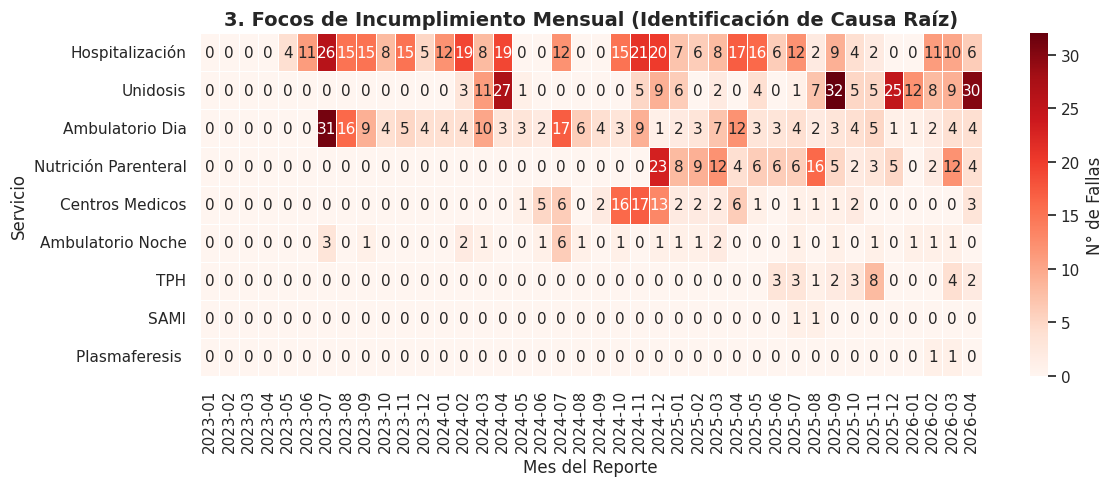

In [ ]:
# ==========================================
# CONCLUSIÓN 3: Mapa de Calor (Foco de Causa Raíz)
# ==========================================
df_calor = df_analisis.copy()
df_calor['AÑO_MES'] = df_calor['FECHA'].dt.strftime('%Y-%m')
matriz_fallas = df_calor.pivot_table(index='SERVICIO', columns='AÑO_MES', values='TOTAL NO CUMPLE', aggfunc='sum', fill_value=0)

# Ordenar la matriz para que los peores servicios queden arriba
matriz_fallas = matriz_fallas.loc[pareto_df['SERVICIO']]

plt.figure(figsize=(12, 5))
sns.heatmap(matriz_fallas, cmap='Reds', annot=True, fmt='.0f', linewidths=.5, cbar_kws={'label': 'N° de Fallas'})
plt.title('3. Focos de Incumplimiento Mensual (Identificación de Causa Raíz)', fontsize=14, fontweight='bold')
plt.xlabel('Mes del Reporte')
plt.ylabel('Servicio')
plt.tight_layout()
plt.show()

/tmp/ipykernel_643/1270173344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico_barras = sns.barplot(


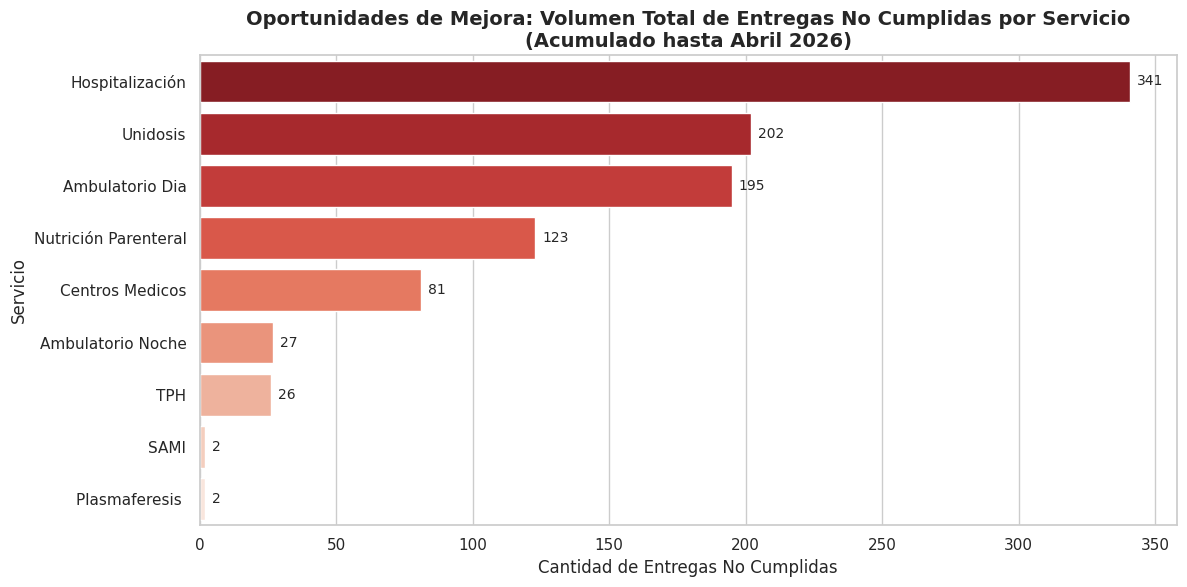

In [ ]:
# Agrupar los datos por servicio sumando los incumplimientos
fallas_por_servicio = df_analisis.groupby('SERVICIO')['TOTAL NO CUMPLE'].sum().reset_index()
fallas_por_servicio = fallas_por_servicio.sort_values('TOTAL NO CUMPLE', ascending=False)

# Crear el gráfico
plt.figure(figsize=(12, 6))
grafico_barras = sns.barplot(
    data=fallas_por_servicio,
    x='TOTAL NO CUMPLE',
    y='SERVICIO',
    palette='Reds_r' # Colores rojos para indicar áreas críticas
)

plt.title('Oportunidades de Mejora: Volumen Total de Entregas No Cumplidas por Servicio\n(Acumulado hasta Abril 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Entregas No Cumplidas', fontsize=12)
plt.ylabel('Servicio', fontsize=12)

# Agregar las etiquetas numéricas a cada barra
for i in grafico_barras.containers:
    grafico_barras.bar_label(i, padding=5, fontsize=10)

plt.tight_layout()
plt.show()

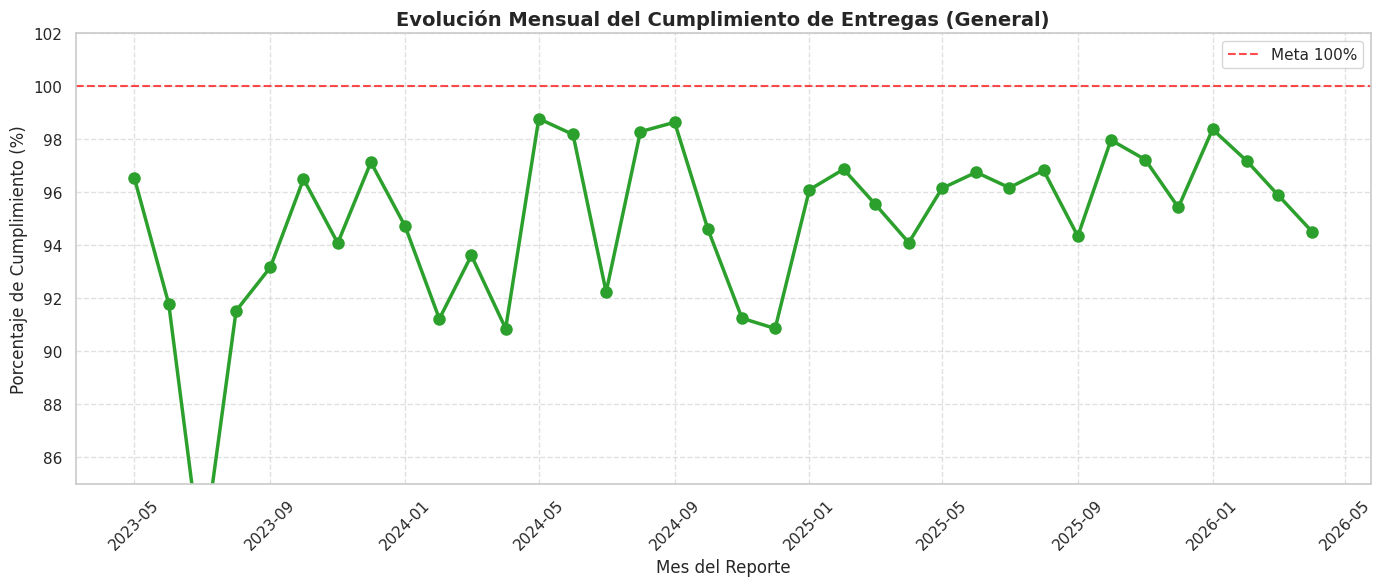

In [ ]:
# Agrupar por mes (año-mes) sumando items totales y cumplidos
evolucion = df_analisis.groupby(df_analisis['FECHA'].dt.to_period('M')).agg(
    TOTAL_ITEMS=('TOTAL ITEMS', 'sum'),
    TOTAL_CUMPLE=('TOTAL CUMPLE', 'sum')
)

# Calcular el porcentaje de cumplimiento
evolucion['PORCENTAJE_REAL'] = (evolucion['TOTAL_CUMPLE'] / evolucion['TOTAL_ITEMS']) * 100

# Convertir el índice para que matplotlib lo grafique correctamente
evolucion.index = evolucion.index.to_timestamp()

# Crear el gráfico
plt.figure(figsize=(14, 6))
plt.plot(evolucion.index, evolucion['PORCENTAJE_REAL'], marker='o', color='#2ca02c', linewidth=2.5, markersize=8)

plt.title('Evolución Mensual del Cumplimiento de Entregas (General)', fontsize=14, fontweight='bold')
plt.xlabel('Mes del Reporte', fontsize=12)
plt.ylabel('Porcentaje de Cumplimiento (%)', fontsize=12)

# Rango del eje Y para destacar las fluctuaciones (por ejemplo de 80% a 105%)
plt.ylim(85, 102)

# Línea de meta ideal (100%)
plt.axhline(y=100, color='red', linestyle='--', alpha=0.7, label='Meta 100%')
plt.legend()

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Disponibilidad del indicador durante 2026

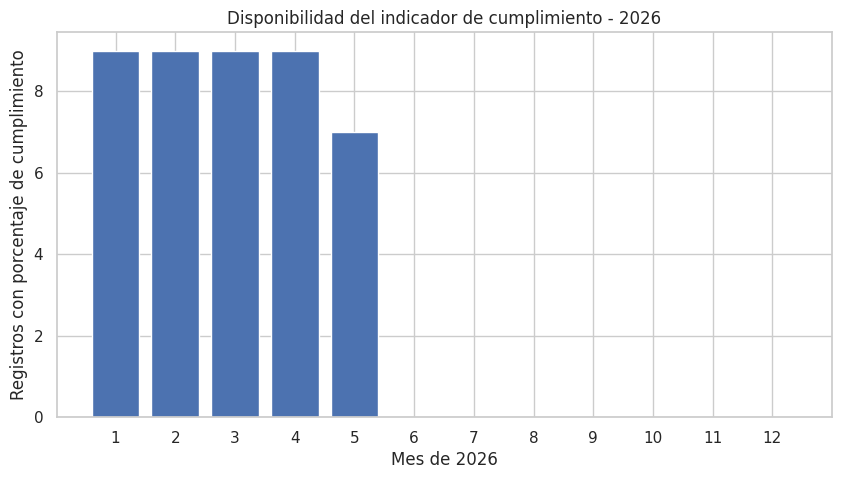

In [ ]:
resumen_grafico = resumen_2026.copy()

plt.figure(figsize=(10,5))

plt.bar(
    resumen_grafico.index,
    resumen_grafico["con_dato"]
)

plt.xlabel("Mes de 2026")
plt.ylabel("Registros con porcentaje de cumplimiento")
plt.title("Disponibilidad del indicador de cumplimiento - 2026")
plt.xticks(range(1,13))

plt.show()

⭐El análisis de disponibilidad evidencia que el indicador de cumplimiento cuenta con información para los primeros meses de 2026. A partir de mayo se identifican registros en la estructura del archivo, pero no se dispone de valores para el porcentaje de cumplimiento. Por esta razón, estos registros no se consideran en el análisis del desempeño, evitando interpretar datos faltantes como incumplimientos.

In [ ]:
import pandas as pd
from google.colab import files

# Seleccionar y cargar el archivo Excel
archivo = files.upload()

# Obtener el nombre del archivo cargado
nombre_archivo = list(archivo.keys())[0]

# Leer el Excel
df = pd.read_excel(nombre_archivo)

print("✅ Archivo cargado correctamente")
print("Nombre:", nombre_archivo)
print("Filas y columnas:", df.shape)

# Mostrar las primeras filas
display(df.head())

KeyboardInterrupt: 

In [ ]:
print(df.columns.tolist())

['AÑO', 'SERVICIO', 'FECHA', 'MES RESUMEN', 'TOTAL CUMPLE', 'TOTAL NO CUMPLE', 'TOTAL ITEMS', 'PORCENTAJE DE CUMPLIMIENTO', 'ANALISIS INDICADOR']


In [ ]:
import pandas as pd
import numpy as np

# Crear una copia del DataFrame
df_reg = df.copy()

# Convertir FECHA a formato fecha
df_reg["FECHA"] = pd.to_datetime(df_reg["FECHA"], errors="coerce")

# Eliminar registros sin fecha
df_reg = df_reg.dropna(subset=["FECHA"])

# Crear período mensual
df_reg["MES"] = df_reg["FECHA"].dt.to_period("M")

# Agrupar por mes
# El cumplimiento se calcula como:
# total de entregas cumplidas / total de ítems
mensual = (
    df_reg.groupby("MES")
    .agg({
        "TOTAL CUMPLE": "sum",
        "TOTAL ITEMS": "sum"
    })
    .reset_index()
)

# Calcular porcentaje de cumplimiento mensual
mensual["PORCENTAJE_CUMPLIMIENTO"] = (
    mensual["TOTAL CUMPLE"] / mensual["TOTAL ITEMS"]
)

# Convertir porcentaje a %
mensual["PORCENTAJE_CUMPLIMIENTO"] *= 100

# Crear un número consecutivo para representar el tiempo
mensual["PERIODO"] = np.arange(len(mensual))

print("✅ Datos preparados para la regresión")
display(mensual)

✅ Datos preparados para la regresión


,MES,TOTAL CUMPLE,TOTAL ITEMS,PORCENTAJE_CUMPLIMIENTO,PERIODO
0,2023-01,0.0,0.0,NaN,0
1,2023-02,0.0,0.0,NaN,1
2,2023-03,0.0,0.0,NaN,2
3,2023-04,0.0,0.0,NaN,3
4,2023-05,111.0,115.0,96.521739,4
5,2023-06,123.0,134.0,91.791045,5
6,2023-07,274.0,334.0,82.035928,6
7,2023-08,335.0,366.0,91.530055,7
8,2023-09,341.0,366.0,93.169399,8
9,2023-10,331.0,343.0,96.501458,9


✅ Datos preparados correctamente
Número de meses analizados: 37


,MES,TOTAL_CUMPLE,TOTAL_ITEMS,PORCENTAJE_CUMPLIMIENTO,PERIODO
0,2023-05,111.0,115.0,96.521739,0
1,2023-06,123.0,134.0,91.791045,1
2,2023-07,274.0,334.0,82.035928,2
3,2023-08,335.0,366.0,91.530055,3
4,2023-09,341.0,366.0,93.169399,4
5,2023-10,331.0,343.0,96.501458,5
6,2023-11,318.0,338.0,94.082840,6
7,2023-12,305.0,314.0,97.133758,7
8,2024-01,287.0,303.0,94.719472,8
9,2024-02,291.0,319.0,91.222571,9



📊 RESULTADOS DE LA REGRESIÓN LINEAL
------------------------------------
Pendiente: 0.1142
Intercepto: 92.7904
R²: 0.1479


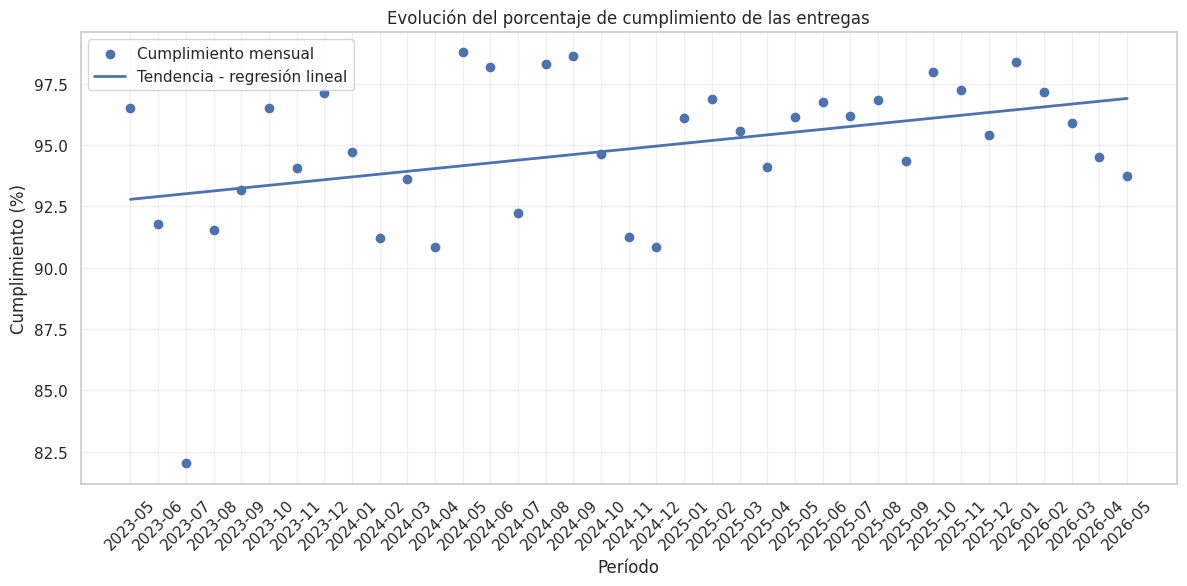

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==========================================
# 1. PREPARAR LOS DATOS
# ==========================================

df_reg = df.copy()

# Convertir fecha
df_reg["FECHA"] = pd.to_datetime(df_reg["FECHA"], errors="coerce")

# Convertir variables numéricas
df_reg["TOTAL CUMPLE"] = pd.to_numeric(
    df_reg["TOTAL CUMPLE"], errors="coerce"
)

df_reg["TOTAL ITEMS"] = pd.to_numeric(
    df_reg["TOTAL ITEMS"], errors="coerce"
)

# Eliminar registros sin fecha
df_reg = df_reg.dropna(subset=["FECHA"])

# Eliminar registros donde no haya información de TOTAL ITEMS
df_reg = df_reg.dropna(subset=["TOTAL ITEMS", "TOTAL CUMPLE"])

# ==========================================
# 2. AGRUPAR POR MES
# ==========================================

df_reg["MES"] = df_reg["FECHA"].dt.to_period("M")

mensual = (
    df_reg.groupby("MES")
    .agg(
        TOTAL_CUMPLE=("TOTAL CUMPLE", "sum"),
        TOTAL_ITEMS=("TOTAL ITEMS", "sum")
    )
    .reset_index()
)

# ==========================================
# 3. CALCULAR CUMPLIMIENTO
# ==========================================

# Evitar división entre cero
mensual = mensual[mensual["TOTAL_ITEMS"] > 0].copy()

mensual["PORCENTAJE_CUMPLIMIENTO"] = (
    mensual["TOTAL_CUMPLE"] / mensual["TOTAL_ITEMS"]
) * 100

# Eliminar cualquier valor que haya quedado vacío
mensual = mensual.replace([np.inf, -np.inf], np.nan)

mensual = mensual.dropna(
    subset=["PORCENTAJE_CUMPLIMIENTO"]
).reset_index(drop=True)

# Crear variable numérica para representar el paso del tiempo
mensual["PERIODO"] = np.arange(len(mensual))

print("✅ Datos preparados correctamente")
print("Número de meses analizados:", len(mensual))

display(mensual)

# ==========================================
# 4. REGRESIÓN LINEAL
# ==========================================

X = mensual[["PERIODO"]]
y = mensual["PORCENTAJE_CUMPLIMIENTO"]

# Verificar que haya suficientes datos
if len(mensual) < 2:
    print("⚠️ No hay suficientes meses para realizar una regresión lineal.")
else:

    modelo = LinearRegression()
    modelo.fit(X, y)

    # Predicciones
    y_pred = modelo.predict(X)

    # Resultados
    pendiente = modelo.coef_[0]
    intercepto = modelo.intercept_
    r2 = r2_score(y, y_pred)

    print("\n📊 RESULTADOS DE LA REGRESIÓN LINEAL")
    print("------------------------------------")
    print(f"Pendiente: {pendiente:.4f}")
    print(f"Intercepto: {intercepto:.4f}")
    print(f"R²: {r2:.4f}")

    # ==========================================
    # 5. GRÁFICO
    # ==========================================

    plt.figure(figsize=(12, 6))

    plt.scatter(
        mensual["MES"].astype(str),
        mensual["PORCENTAJE_CUMPLIMIENTO"],
        label="Cumplimiento mensual"
    )

    plt.plot(
        mensual["MES"].astype(str),
        y_pred,
        linewidth=2,
        label="Tendencia - regresión lineal"
    )

    plt.title(
        "Evolución del porcentaje de cumplimiento de las entregas"
    )

    plt.xlabel("Período")
    plt.ylabel("Cumplimiento (%)")

    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()